In [ ]:

# Install required packages (run once)
!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.2.0+cu121.html -q
!pip install sentence-transformers umap-learn -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 29.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 946.2/946.2 kB 16.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# MAPCT-v12: HYBRID NORMALIZING FLOW + GRAPH NEURAL NETWORK
# ============================================================
# Combines:
# 1. Normalizing Flow for flexible latent distribution
# 2. GNN for drug-drug interaction modeling
# 3. Semantic + Structured mechanism embeddings
# 4. Contrastive learning for alignment
# 5. Fast sampling with exact likelihood
# ============================================================

# Imports
import os
import re
import random
import hashlib
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
from itertools import combinations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Check for torch_geometric
try:
    from torch_geometric.nn import GCNConv, GATConv, SAGEConv
    TORCH_GEOMETRIC_AVAILABLE = True
except ImportError:
    print("⚠️ torch_geometric not installed. Installing...")
    TORCH_GEOMETRIC_AVAILABLE = False
    raise ImportError("Please install torch_geometric first")

# Optional UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP not available, will use t-SNE only")

from sentence_transformers import SentenceTransformer

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Constants
MAX_DRUGS = 10
BATCH_SIZE = 32
EMBED_DIM = 128



Using device: cpu


In [ ]:
# ============================================================
# SECTION 0: DRUG NAME UTILITIES
# ============================================================

def normalize_drug_name(name: str) -> str:
    """Normalize drug name by removing extra text and standardizing format"""
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()


def sort_drug_combo(combo: str) -> str:
    """Sort drugs in a combination alphabetically"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    drugs = sorted(drugs)
    return ", ".join(drugs)


def split_combo(combo: str) -> List[str]:
    """Split drug combination into individual drugs"""
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]


def deduplicate_combo(combo: str) -> str:
    """Remove duplicate drugs from combination"""
    drugs = split_combo(combo)
    unique_drugs = sorted(set(drugs))
    return ", ".join(unique_drugs)



In [ ]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# Apply normalization and sorting
clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
    .apply(deduplicate_combo)
)

print(f"✅ Drug names normalized")
print(f"   Unique regimens: {clinic_df['merged_drugs_norm'].nunique()}")

# Create hba1c_category from numeric hba1c
def categorize_hba1c(val):
    if pd.isna(val):
        return 'Unknown'
    if val < 5.7:
        return 'Normal'
    elif val < 6.5:
        return 'Prediabetes'
    else:
        return 'Diabetes'

clinic_df['hba1c_category'] = clinic_df['hba1c'].apply(categorize_hba1c)
print(f"   hba1c categories: {clinic_df['hba1c_category'].unique()}")



Mounted at /content/drive
Loaded 4547 patients, 164 mechanism entries
✅ Drug names normalized
   Unique regimens: 1365
   hba1c categories: ['Diabetes' 'Prediabetes' 'Normal']


In [ ]:
# ============================================================
# SECTION 2: LEAKAGE‑FREE SPLIT BY REGIMEN (GROUP‑BASED)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings (normalized)
groups = clinic_df["merged_drugs_norm"].values

# Step 1: Split off test set (20% of groups) → ~20% of patients
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Step 2: From remaining groups, split off validation (20% of those groups)
# This gives validation = 0.2 * 0.8 = 16% of total patients
groups_train_val = groups[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert relative indices to original indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]

print(f"Splits: Train={len(idx_train)} ({len(idx_train)/len(clinic_df)*100:.1f}%), "
      f"Val={len(idx_val)} ({len(idx_val)/len(clinic_df)*100:.1f}%), "
      f"Test={len(idx_test)} ({len(idx_test)/len(clinic_df)*100:.1f}%)")

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "LEAKAGE DETECTED: train and test share a regimen!"

# Create dataframes for each split (your later code expects these)
train_df = clinic_df.iloc[idx_train].copy()
val_df = clinic_df.iloc[idx_val].copy()
test_df = clinic_df.iloc[idx_test].copy()


print(f"Train combos: {len(train_combos)}")
print(f"Test combos:  {len(test_combos)}")
print(f"Overlap: {len(train_combos & test_combos)}")  # must be 0


# ============================================================
# SECTION 3: DRUG VOCABULARY (TRAIN ONLY)
# ============================================================

def build_drug_vocabulary(train_df):
    """Build drug vocabulary from training data only"""
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx):
    """Convert drug combination to multi-hot encoding"""
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

def filter_to_train_vocab(combo, drug_to_idx):
    """Filter out drugs not in training vocabulary"""
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

# Build vocabulary
drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs}")

# Filter validation and test sets
val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))




Splits: Train=3182, Val=455, Test=910
Drug vocabulary size: 160


In [ ]:
# ============================================================
# SECTION 4: CLINICAL PREPROCESSING
# ============================================================

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])
X_train = np.hstack([X_num_train, X_cat_train])

X_num_val = scaler.transform(val_df[numeric_cols])
X_cat_val = ohe.transform(val_df[categorical_cols])
X_val = np.hstack([X_num_val, X_cat_val])

X_num_test = scaler.transform(test_df[numeric_cols])
X_cat_test = ohe.transform(test_df[categorical_cols])
X_test = np.hstack([X_num_test, X_cat_test])

print(f"Clinical feature dimension: {X_train.shape[1]}")


# ============================================================
# SECTION 5: MECHANISM EMBEDDINGS (Structured + Semantic)
# ============================================================

def stable_hash(x: str, mod: int) -> int:
    """Stable hash function for encoding categorical features"""
    return int(hashlib.md5(x.encode()).hexdigest(), 16) % mod


class StructuredMechanismEncoder:
    """Encode drug mechanisms using structured hashing"""

    def __init__(self, struct_dim=128):
        self.struct_dim = struct_dim
        self.n_fields = 8
        self.slice_len = struct_dim // self.n_fields

        self.offsets = {
            "chembl": 0,
            "target_ids": self.slice_len,
            "uniprot_ids": 2 * self.slice_len,
            "mesh_ids": 3 * self.slice_len,
            "pathway_ids": 4 * self.slice_len,
            "atc_codes": 5 * self.slice_len,
            "pharm_class": 6 * self.slice_len,
            "mechanism_ids": 7 * self.slice_len,
        }

        self.field_columns = {
            "chembl": "ChEMBL ID",
            "target_ids": "Target IDs",
            "uniprot_ids": "UniProt Target ID(s)",
            "mesh_ids": "MeSH Mechanism ID(s)",
            "pathway_ids": "Pathway IDs",
            "atc_codes": "ATC Code(s)",
            "pharm_class": "Pharmacologic Class",
            "mechanism_ids": "Mechanism IDs",
        }

    def encode_field(self, values, field_name):
        """Encode a single field using hashing trick"""
        vector = torch.zeros(self.slice_len)
        if values is None:
            return vector
        if isinstance(values, pd.Series):
            values = values.dropna().tolist()
        elif isinstance(values, str):
            values = [v.strip() for v in values.split(";") if v.strip()]
        elif not isinstance(values, (list, tuple)):
            values = [values]

        for v in values:
            v_str = str(v).strip()
            if v_str and v_str not in ["", "nan", "None"]:
                idx = stable_hash(v_str, self.slice_len)
                vector[idx] += 1.0
        return vector

    def encode(self, row):
        """Encode entire drug mechanism row"""
        vector = torch.zeros(self.struct_dim)
        for field_name, col_name in self.field_columns.items():
            if col_name in row.index:
                vals = row[col_name]
                field_vec = self.encode_field(vals, field_name)
                offset = self.offsets[field_name]
                vector[offset:offset + self.slice_len] = field_vec
        if torch.norm(vector) > 0:
            vector = vector / torch.norm(vector)
        return vector


def build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128):
    """Build hybrid mechanism embeddings (structured + semantic)"""
    print("\n" + "="*70)
    print("🔬 BUILDING MECHANISM EMBEDDINGS (Semantic + Structured)")
    print("="*70)

    semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    sem_dim = semantic_model.get_sentence_embedding_dimension()
    print(f"   Semantic dimension: {sem_dim}")

    struct_encoder = StructuredMechanismEncoder(struct_dim=embed_dim)

    embeddings = {}
    missing_drugs = []

    for drug in tqdm(train_drugs, desc="Building embeddings"):
        row = mech_df[mech_df["Drug Name Norm"] == drug]

        if len(row) > 0:
            row = row.iloc[0]
            struct_vec = struct_encoder.encode(row)

            text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]
            text_parts = []
            for col in text_cols:
                if col in row and pd.notna(row[col]):
                    text_parts.append(str(row[col]))

            if text_parts:
                full_text = " | ".join(text_parts)
                with torch.no_grad():
                    sem_vec = semantic_model.encode(full_text, convert_to_tensor=True)
                    sem_vec = F.normalize(sem_vec, dim=0).cpu()
            else:
                sem_vec = torch.zeros(sem_dim)

            fused = torch.cat([struct_vec, sem_vec], dim=0)
            if torch.norm(fused) > 0:
                fused = fused / torch.norm(fused)

            embeddings[drug] = fused
        else:
            embeddings[drug] = torch.zeros(embed_dim + sem_dim)
            missing_drugs.append(drug)

    if missing_drugs:
        print(f"   ⚠️ No mechanism data for {len(missing_drugs)} drugs")

    print(f"✅ Built embeddings for {len(embeddings)} drugs")
    print(f"   Embedding dimension: {embed_dim + sem_dim}")

    return embeddings, embed_dim + sem_dim


# Build embeddings
train_drugs = set(drug_to_idx.keys())
drug_embeddings, full_embed_dim = build_mechanism_embeddings(train_drugs, mech_df, embed_dim=EMBED_DIM)
print(f"Full embedding dimension: {full_embed_dim}")




Clinical feature dimension: 25

🔬 BUILDING MECHANISM EMBEDDINGS (Semantic + Structured)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Semantic dimension: 384


Building embeddings: 100%|██████████| 160/160 [00:22<00:00,  7.18it/s]

   ⚠️ No mechanism data for 55 drugs
✅ Built embeddings for 160 drugs
   Embedding dimension: 512
Full embedding dimension: 512


In [ ]:
# ============================================================
# SECTION 6: BUILD DRUG SIMILARITY GRAPH (for GNN)
# ============================================================

def build_drug_similarity_graph(drug_embeddings, drug_vocab, similarity_threshold=0.5):
    """Build drug similarity graph based on mechanism embeddings"""
    print("\n" + "="*70)
    print("📊 BUILDING DRUG SIMILARITY GRAPH")
    print("="*70)

    n_drugs = len(drug_vocab)
    edge_index = []
    edge_weights = []

    for i, drug1 in enumerate(drug_vocab):
        emb1 = drug_embeddings.get(drug1, torch.zeros(full_embed_dim))
        for j, drug2 in enumerate(drug_vocab):
            if i < j:
                emb2 = drug_embeddings.get(drug2, torch.zeros(full_embed_dim))
                sim = torch.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

                if sim > similarity_threshold:
                    edge_index.append([i, j])
                    edge_index.append([j, i])
                    edge_weights.append(sim)
                    edge_weights.append(sim)

    if len(edge_index) == 0:
        # Add self-loops if no edges
        edge_index = [[i, i] for i in range(n_drugs)]
        edge_weights = [1.0] * n_drugs

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weights = torch.tensor(edge_weights, dtype=torch.float32)

    print(f"   Created graph with {n_drugs} nodes and {edge_index.shape[1]} edges")
    print(f"   Average degree: {edge_index.shape[1] / n_drugs:.2f}")

    return edge_index, edge_weights


drug_edge_index, drug_edge_weights = build_drug_similarity_graph(
    drug_embeddings, drug_vocab, similarity_threshold=0.5
)





📊 BUILDING DRUG SIMILARITY GRAPH
   Created graph with 160 nodes and 176 edges
   Average degree: 1.10


In [ ]:
# ============================================================
# SECTION 7: NORMALIZING FLOW + GNN COMPONENTS
# ============================================================

class RealNVPCouplingLayer(nn.Module):
    """Real NVP coupling layer for normalizing flow"""

    def __init__(self, dim, hidden_dim=256):
        super().__init__()
        self.dim = dim
        mask = torch.zeros(dim)
        mask[:dim//2] = 1
        self.register_buffer('mask', mask)

        self.scale_net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim), nn.Tanh()
        )
        self.translation_net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x, reverse=False):
        x1 = x * self.mask
        x2 = x * (1 - self.mask)

        if not reverse:
            scale = self.scale_net(x1) * (1 - self.mask)
            translation = self.translation_net(x1) * (1 - self.mask)
            x2_out = x2 * torch.exp(scale) + translation
            log_det = (scale * (1 - self.mask)).sum(dim=1)
            return x1 + x2_out, log_det
        else:
            scale = self.scale_net(x1) * (1 - self.mask)
            translation = self.translation_net(x1) * (1 - self.mask)
            x2_out = (x2 - translation) * torch.exp(-scale)
            log_det = -(scale * (1 - self.mask)).sum(dim=1)
            return x1 + x2_out, log_det


class DrugMechanismGNN(nn.Module):
    """GNN for encoding drug mechanisms with graph attention"""

    def __init__(self, node_dim=full_embed_dim, hidden_dim=128, latent_dim=128,
                 n_layers=2, gnn_type='gat', n_heads=4, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Linear(node_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(n_layers):
            if gnn_type == 'gcn':
                conv = GCNConv(hidden_dim, hidden_dim)
            elif gnn_type == 'gat':
                conv = GATConv(hidden_dim, hidden_dim, heads=n_heads, concat=False, dropout=dropout)
            elif gnn_type == 'sage':
                conv = SAGEConv(hidden_dim, hidden_dim)
            else:
                raise ValueError(f"Unknown GNN type: {gnn_type}")

            self.convs.append(conv)
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.dropout = nn.Dropout(dropout)
        self.output_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.input_proj(x)

        for i, conv in enumerate(self.convs):
            if edge_weight is not None:
                x_new = conv(x, edge_index, edge_weight)
            else:
                x_new = conv(x, edge_index)

            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x_new = self.dropout(x_new)
            x = x + x_new  # Residual connection

        return F.normalize(self.output_proj(x), dim=1)


class FlowGNNRegimenEncoder(nn.Module):
    """Hybrid encoder combining GNN and Normalizing Flow"""

    def __init__(self, drug_gnn, flow_layers, latent_dim=128):
        super().__init__()
        self.drug_gnn = drug_gnn
        self.flow_layers = flow_layers
        self.latent_dim = latent_dim

        # Projection after GNN
        self.gnn_proj = nn.Linear(latent_dim, latent_dim)

        # Base distribution
        self.base_dist = Normal(torch.zeros(latent_dim), torch.ones(latent_dim))

    def forward_flow(self, z, reverse=False):
        """Apply flow transformations"""
        log_det = 0
        current = z

        if not reverse:
            for layer in self.flow_layers:
                current, ld = layer(current, reverse=False)
                log_det += ld
            return current, log_det
        else:
            for layer in reversed(self.flow_layers):
                current, ld = layer(current, reverse=True)
                log_det += ld
            return current, log_det

    def forward(self, global_mech_tensor, mech_tensor, drug_indices, mask,
                graph_edge_index, graph_weights=None):
        """
        Args:
            global_mech_tensor: [num_drugs, embed_dim] - static mechanism embeddings
            mech_tensor: [batch, max_drugs, embed_dim] - mechanism features per drug slot
            drug_indices: [batch, max_drugs] - integer indices into drug_vocab, -1 for padding
            mask: [batch, max_drugs] - boolean, True for real drugs
            graph_edge_index: [2, num_edges] - drug similarity graph edges
            graph_weights: [num_edges] - edge weights
        """
        batch_size, max_drugs, embed_dim = mech_tensor.shape

        # Step 1: Get GNN-enhanced drug embeddings
        drug_embeddings_gnn = self.drug_gnn(global_mech_tensor, graph_edge_index, graph_weights)

        # Step 2: Gather embeddings for each patient's drugs
        valid_mask = drug_indices >= 0
        drug_indices_safe = drug_indices.clone()
        drug_indices_safe[~valid_mask] = 0
        gnn_enhanced = drug_embeddings_gnn[drug_indices_safe]
        gnn_enhanced = gnn_enhanced * mask.unsqueeze(-1).float()

        # Step 3: Masked pooling
        mask_expanded = mask.unsqueeze(-1).float()
        z_gnn = (gnn_enhanced * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        z_gnn = self.gnn_proj(z_gnn)

        # Step 4: Apply normalizing flow
        z_flow, log_det = self.forward_flow(z_gnn, reverse=False)

        return z_flow, z_gnn, log_det

    def log_prob(self, z):
        """Compute log probability under flow distribution"""
        z_base, log_det = self.forward_flow(z, reverse=True)
        log_prob_base = self.base_dist.log_prob(z_base).sum(dim=1)
        return log_prob_base + log_det

    def sample(self, num_samples):
        """Generate samples from learned distribution"""
        z_base = self.base_dist.sample((num_samples,))
        z_flow, _ = self.forward_flow(z_base, reverse=False)
        return z_flow


class ClinicalEncoder(nn.Module):
    """Encode clinical features into latent space"""

    def __init__(self, input_dim, latent_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, latent_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


class DrugDecoder(nn.Module):
    """Decode latent representations to drug predictions"""

    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)


class MAPCTv12Hybrid(nn.Module):
    """
    MAPCT-v12: Hybrid Normalizing Flow + GNN

    Key innovations:
    1. GNN for drug-drug interaction modeling
    2. Normalizing Flow for flexible latent distribution
    3. Semantic + structured mechanism embeddings
    4. Contrastive learning with exact likelihood
    """

    def __init__(self, clin_dim, num_drugs, drug_graph_edge_index, drug_graph_weights,
                 latent_dim=128, n_flow_layers=4, gnn_type='gat', n_gnn_layers=2):
        super().__init__()

        # Register drug graph
        self.register_buffer('drug_graph_edge_index', drug_graph_edge_index)
        self.register_buffer('drug_graph_weights', drug_graph_weights)

        # Build global mechanism tensor
        global_mech_tensor = torch.stack([drug_embeddings[drug] for drug in drug_vocab])
        self.register_buffer('global_mech_tensor', global_mech_tensor)

        # Drug mechanism GNN
        self.drug_gnn = DrugMechanismGNN(
            node_dim=full_embed_dim,
            hidden_dim=latent_dim,
            latent_dim=latent_dim,
            n_layers=n_gnn_layers,
            gnn_type=gnn_type
        )

        # Normalizing flow layers
        flow_layers = nn.ModuleList([
            RealNVPCouplingLayer(latent_dim) for _ in range(n_flow_layers)
        ])

        # Hybrid regimen encoder (GNN + Flow)
        self.regimen_encoder = FlowGNNRegimenEncoder(
            drug_gnn=self.drug_gnn,
            flow_layers=flow_layers,
            latent_dim=latent_dim
        )

        # Clinical encoder
        self.clinical_encoder = ClinicalEncoder(clin_dim, latent_dim)

        # Drug decoder
        self.drug_decoder = DrugDecoder(latent_dim, num_drugs=num_drugs)

    def forward(self, clinical, mech_tensor, mech_mask, drug_indices):
        """Forward pass through the model"""
        # Encode clinical features
        z_clin = self.clinical_encoder(clinical)

        # Encode regimen mechanisms (GNN + Flow)
        z_reg, z_gnn, log_det = self.regimen_encoder(
            self.global_mech_tensor,
            mech_tensor, drug_indices, mech_mask,
            self.drug_graph_edge_index,
            self.drug_graph_weights
        )

        # Decode to drug predictions
        logits = self.drug_decoder(z_clin)

        return logits, z_clin, z_reg, z_gnn, log_det

    def get_drug_embeddings(self):
        """Get GNN-enhanced embeddings for all drugs"""
        return self.drug_gnn(self.global_mech_tensor,
                            self.drug_graph_edge_index,
                            self.drug_graph_weights)

    def generate_regimens(self, clinical_tensor, drug_vocab, num_samples=5, threshold=0.3):
        """Generate personalized regimens using clinical latent code"""
        self.eval()
        generated = []
        with torch.no_grad():
            z_clin = self.clinical_encoder(clinical_tensor)

            # Deterministic prediction
            logits = self.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).detach().cpu().numpy().squeeze()

            drugs = [(drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
            drugs.sort(key=lambda x: x[1], reverse=True)

            if drugs:
                generated.append({
                    'regimen': ", ".join([d for d, _ in drugs[:5]]),
                    'drugs': drugs[:10],
                    'num_drugs': len(drugs),
                    'confidence': drugs[0][1]
                })
        return generated




In [ ]:
# ============================================================
# SECTION 8: DATASET CLASS
# ============================================================

def build_regimen_mechanism_tensor(combo, drug_embeddings, max_drugs=MAX_DRUGS, embed_dim=full_embed_dim):
    """Build mechanism tensor for a drug combination"""
    drugs = split_combo(combo)[:max_drugs]
    tensor = torch.zeros(max_drugs, embed_dim)
    for i, drug in enumerate(drugs):
        emb = drug_embeddings.get(drug, torch.zeros(embed_dim))
        tensor[i] = emb
    mask = torch.zeros(max_drugs, dtype=torch.bool)
    mask[:len(drugs)] = True
    return tensor, mask


class RegimenDataset(Dataset):
    """Dataset for regimen generation"""

    def __init__(self, df, clinical_features, drug_to_idx, drug_embeddings, embed_dim=full_embed_dim):
        self.df = df.reset_index(drop=True)
        self.clinical_features = clinical_features
        self.drug_to_idx = drug_to_idx
        self.drug_embeddings = drug_embeddings
        self.embed_dim = embed_dim
        self.num_drugs = len(drug_to_idx)

        # Precompute labels
        self.labels = []
        for _, row in self.df.iterrows():
            label = encode_regimen_multi_hot(row["merged_drugs_norm"], drug_to_idx)
            self.labels.append(label)

        # Precompute mechanism tensors
        self.mech_tensors = []
        self.mech_masks = []
        for _, row in self.df.iterrows():
            tensor, mask = build_regimen_mechanism_tensor(row["merged_drugs_norm"], drug_embeddings)
            self.mech_tensors.append(tensor)
            self.mech_masks.append(mask)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        combo = self.df.iloc[idx]["merged_drugs_norm"]
        drug_list = split_combo(combo)[:MAX_DRUGS]
        indices = [self.drug_to_idx.get(d, -1) for d in drug_list]
        indices += [-1] * (MAX_DRUGS - len(indices))
        drug_indices_tensor = torch.tensor(indices, dtype=torch.long)

        return {
            'clinical': torch.tensor(self.clinical_features[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'mech_tensor': self.mech_tensors[idx],
            'mech_mask': self.mech_masks[idx],
            'drug_indices': drug_indices_tensor
        }


# Create datasets
train_dataset = RegimenDataset(train_df, X_train, drug_to_idx, drug_embeddings)
val_dataset = RegimenDataset(val_df, X_val, drug_to_idx, drug_embeddings)
test_dataset = RegimenDataset(test_df, X_test, drug_to_idx, drug_embeddings)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")




Train batches: 100, Val batches: 15, Test batches: 29


In [ ]:
# ============================================================
# SECTION 9: LOSS FUNCTIONS
# ============================================================

def contrastive_loss(z1, z2, temperature=0.07):
    """InfoNCE contrastive loss for alignment"""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2

def flow_kl_loss(z_flow, log_det):
    """KL divergence for normalizing flow (exact likelihood) - FIXED to be positive"""
    latent_dim = z_flow.shape[1]
    # Standard KL: 0.5 * (||z||^2 - 2*log_det - D)
    kl = 0.5 * (z_flow.pow(2).sum(dim=1) - 2 * log_det - latent_dim)
    return kl.mean()


def graph_regularization_loss(embeddings, edge_index):
    """Smoothness regularization on graph"""
    if edge_index.shape[1] == 0:
        return torch.tensor(0.0, device=embeddings.device)
    source = edge_index[0]
    target = edge_index[1]
    diff = embeddings[source] - embeddings[target]
    return (diff ** 2).sum(dim=1).mean()




In [ ]:
# ============================================================
# SECTION 10: MAPCT-v12 TRAINER
# ============================================================

class MAPCTv12Trainer:
    """Trainer for MAPCT-v12 with comprehensive metrics tracking"""

    def __init__(self, model, device, drug_vocab, drug_to_idx, drug_graph_edge_index):
        self.model = model.to(device)
        self.device = device
        self.drug_vocab = drug_vocab
        self.drug_to_idx = drug_to_idx
        self.idx_to_drug = {v: k for k, v in drug_to_idx.items()}
        self.drug_graph_edge_index = drug_graph_edge_index.to(device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-3, weight_decay=1e-5)

        # Loss weights
        self.alpha_contrast = 0.8
        self.beta_drug = 1.0
        self.gamma_flow = 0.01
        self.delta_graph = 0.005

        self.train_losses = []
        self.val_losses = []
        self.history = defaultdict(list)

    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        metrics = defaultdict(float)

        for batch in tqdm(train_loader, desc="Training"):
            clinical = batch['clinical'].to(self.device)
            labels = batch['label'].to(self.device)
            mech_tensor = batch['mech_tensor'].to(self.device)
            mech_mask = batch['mech_mask'].to(self.device)
            drug_indices = batch['drug_indices'].to(self.device)

            logits, z_clin, z_reg, z_gnn, log_det = self.model(clinical, mech_tensor, mech_mask, drug_indices)

            # Drug prediction loss
            loss_drug = F.binary_cross_entropy_with_logits(logits, labels)

            # Contrastive loss
            loss_contrast = contrastive_loss(z_clin, z_reg)

            # Flow KL loss (exact likelihood)
            loss_flow = flow_kl_loss(z_reg, log_det)

            # Graph regularization
            drug_embs = self.model.get_drug_embeddings()
            loss_graph = graph_regularization_loss(drug_embs, self.drug_graph_edge_index)

            # Combined loss
            loss = (self.beta_drug * loss_drug +
                   self.alpha_contrast * loss_contrast +
                   self.gamma_flow * loss_flow +
                   self.delta_graph * loss_graph)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            metrics['loss'] += loss.item()
            metrics['drug'] += loss_drug.item()
            metrics['contrast'] += loss_contrast.item()
            metrics['flow'] += loss_flow.item()
            metrics['graph'] += loss_graph.item()

        n_batches = len(train_loader)
        for k in metrics:
            metrics[k] /= n_batches

        return metrics

    def validate(self, val_loader):
        """Validate the model"""
        self.model.eval()
        total_contrast = 0
        total_drug_acc = 0
        total_flow = 0

        with torch.no_grad():
            for batch in val_loader:
                clinical = batch['clinical'].to(self.device)
                labels = batch['label'].to(self.device)
                mech_tensor = batch['mech_tensor'].to(self.device)
                mech_mask = batch['mech_mask'].to(self.device)
                drug_indices = batch['drug_indices'].to(self.device)

                logits, z_clin, z_reg, _, log_det = self.model(clinical, mech_tensor, mech_mask, drug_indices)

                loss_contrast = contrastive_loss(z_clin, z_reg)
                total_contrast += loss_contrast.item()

                loss_flow = flow_kl_loss(z_reg, log_det)
                total_flow += loss_flow.item()

                preds = (torch.sigmoid(logits) > 0.5).float()
                total_drug_acc += (preds == labels).float().mean().item()

        n_batches = len(val_loader)
        return {
            'contrast_loss': total_contrast / n_batches,
            'drug_accuracy': total_drug_acc / n_batches,
            'flow_loss': total_flow / n_batches
        }

    def train(self, train_loader, val_loader, epochs=50, patience=10):
        """Main training loop"""
        best_val_acc = 0.0
        patience_counter = 0

        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.validate(val_loader)

            # Store metrics
            self.train_losses.append(train_metrics['loss'])

            for key, value in train_metrics.items():
                self.history[key].append(value)

            # Store validation metrics
            self.history['val_contrast'].append(val_metrics['contrast_loss'])
            self.history['val_accuracy'].append(val_metrics['drug_accuracy'])
            self.history['val_flow'].append(val_metrics['flow_loss'])

            # Print progress
            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1}/{epochs}")
                print(f"  Train - Loss: {train_metrics['loss']:.4f}, Drug: {train_metrics['drug']:.4f}")
                print(f"  Train - Contrast: {train_metrics['contrast']:.4f}, Flow: {train_metrics['flow']:.4f}")
                print(f"  Valid - Contrast: {val_metrics['contrast_loss']:.4f}, Drug Acc: {val_metrics['drug_accuracy']:.4f}")

            # Early stopping
            if val_metrics['drug_accuracy'] > best_val_acc:
                best_val_acc = val_metrics['drug_accuracy']
                patience_counter = 0
                self.save_checkpoint('best_flow_gnn_model.pt')
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\n✅ Training complete! Best validation accuracy: {best_val_acc:.4f}")
        return self.history

    def save_checkpoint(self, path):
        """Save model checkpoint"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'drug_to_idx': self.drug_to_idx,
            'idx_to_drug': self.idx_to_drug,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'history': dict(self.history),
        }, path)
        print(f"✅ Model saved to {path}")

    def load_checkpoint(self, path):
        """Load model checkpoint"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.drug_to_idx = checkpoint['drug_to_idx']
        self.idx_to_drug = checkpoint['idx_to_drug']
        self.train_losses = checkpoint.get('train_losses', [])
        self.val_losses = checkpoint.get('val_losses', [])
        self.history = defaultdict(list, checkpoint.get('history', {}))
        print(f"✅ Model loaded from {path}")

In [ ]:
# ============================================================
# SECTION 11: EVALUATION AND VISUALIZATION FUNCTIONS
# ============================================================

def evaluate_drug_predictions(trainer, test_loader, threshold=0.3):
    """Evaluate drug-level predictions"""
    print("\n" + "="*70)
    print("📊 DRUG PREDICTION EVALUATION")
    print("="*70)

    trainer.model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            logits, _, _, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs > threshold).astype(np.float32)

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    results = {
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'accuracy': accuracy_score(all_labels.flatten(), all_preds.flatten())
    }

    print(f"\n📈 Micro-averaged Metrics:")
    print(f"   Precision: {results['precision']:.4f}")
    print(f"   Recall:    {results['recall']:.4f}")
    print(f"   F1-Score:  {results['f1']:.4f}")
    print(f"   Accuracy:  {results['accuracy']:.4f}")

    return results


def compute_test_latents(model, test_loader, device):
    """Compute clinical and regimen latent vectors for all test samples"""
    model.eval()
    z_clin_list = []
    z_reg_list = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Computing test latents"):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = model(clinical, mech_tensor, mech_mask, drug_indices)

            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

    z_clin_test = np.vstack(z_clin_list)
    z_reg_test = np.vstack(z_reg_list)
    return z_clin_test, z_reg_test


def visualize_latent_spaces(z_clin, z_reg, test_df, save_path=None):
    """Visualize clinical and regimen latent spaces with PCA"""
    print("\n" + "="*70)
    print("🎨 LATENT SPACE VISUALIZATION")
    print("="*70)

    # Use hba1c_category for coloring
    hba1c_labels = test_df['hba1c_category'].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # PCA for clinical latent space
    pca = PCA(n_components=2, random_state=SEED)
    z_clin_pca = pca.fit_transform(z_clin)

    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        axes[0].scatter(z_clin_pca[mask, 0], z_clin_pca[mask, 1],
                       label=cat, alpha=0.6, s=20, color=color)
    axes[0].set_title('Clinical Latent Space (PCA)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # PCA for regimen latent space
    z_reg_pca = pca.fit_transform(z_reg)
    axes[1].scatter(z_reg_pca[:, 0], z_reg_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title('Regimen Flow-GNN Latent Space (PCA)')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v12: Hybrid Flow-GNN Latent Spaces', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return z_clin_pca, z_reg_pca


def plot_training_history(trainer, save_path=None):
    """Plot training loss curves"""
    print("\n" + "="*70)
    print("📈 TRAINING HISTORY")
    print("="*70)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Total loss
    axes[0, 0].plot(trainer.train_losses, 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Training Loss')
    axes[0, 0].grid(True, alpha=0.3)

    # Contrastive loss
    axes[0, 1].plot(trainer.history.get('contrast', []), 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Contrastive Loss')
    axes[0, 1].set_title('InfoNCE Contrastive Loss')
    axes[0, 1].grid(True, alpha=0.3)

    # Drug loss
    axes[1, 0].plot(trainer.history.get('drug', []), 'r-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Drug Loss')
    axes[1, 0].set_title('Drug Prediction Loss (BCE)')
    axes[1, 0].grid(True, alpha=0.3)

    # Flow loss
    axes[1, 1].plot(trainer.history.get('flow', []), 'purple', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Flow Loss')
    axes[1, 1].set_title('Normalizing Flow KL Loss')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Final Training Loss: {trainer.train_losses[-1]:.4f}" if trainer.train_losses else "No training data")

# ============================================================
# ADD THESE FUNCTIONS FOR t-SNE AND UMAP VISUALIZATIONS
# ============================================================

def visualize_tsne_latent_spaces(z_clin, z_reg, test_df, save_path=None, perplexity=30):
    """t-SNE visualization of clinical and regimen latent spaces"""
    print("\n" + "="*70)
    print("🎨 T-SNE LATENT SPACE VISUALIZATION")
    print("="*70)

    hba1c_labels = test_df['hba1c_category'].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, max_iter=1000)
    z_clin_tsne = tsne.fit_transform(z_clin)

    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        if mask.sum() > 0:
            axes[0].scatter(z_clin_tsne[mask, 0], z_clin_tsne[mask, 1],
                           label=cat, alpha=0.6, s=20, color=color)
    axes[0].set_title(f'Clinical Latent Space (t-SNE, perplexity={perplexity})')
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    z_reg_tsne = tsne.fit_transform(z_reg)
    axes[1].scatter(z_reg_tsne[:, 0], z_reg_tsne[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title(f'Regimen Latent Space (t-SNE, perplexity={perplexity})')
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v12: t-SNE Visualization of Latent Spaces', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ t-SNE plot saved as '{save_path if save_path else 'tsne_plot.png'}'")

    return z_clin_tsne, z_reg_tsne


def visualize_umap_latent_spaces(z_clin, z_reg, test_df, save_path=None, n_neighbors=15):
    """UMAP visualization of clinical and regimen latent spaces"""
    if not UMAP_AVAILABLE:
        print("⚠️ UMAP not installed. Install with: pip install umap-learn")
        return None, None

    print("\n" + "="*70)
    print("🎨 UMAP LATENT SPACE VISUALIZATION")
    print("="*70)

    hba1c_labels = test_df['hba1c_category'].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    reducer = umap.UMAP(random_state=SEED, n_components=2, n_neighbors=n_neighbors)
    z_clin_umap = reducer.fit_transform(z_clin)

    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask = hba1c_labels == cat
        if mask.sum() > 0:
            axes[0].scatter(z_clin_umap[mask, 0], z_clin_umap[mask, 1],
                           label=cat, alpha=0.6, s=20, color=color)
    axes[0].set_title(f'Clinical Latent Space (UMAP, n_neighbors={n_neighbors})')
    axes[0].set_xlabel('UMAP Dimension 1')
    axes[0].set_ylabel('UMAP Dimension 2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    z_reg_umap = reducer.fit_transform(z_reg)
    axes[1].scatter(z_reg_umap[:, 0], z_reg_umap[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title(f'Regimen Latent Space (UMAP, n_neighbors={n_neighbors})')
    axes[1].set_xlabel('UMAP Dimension 1')
    axes[1].set_ylabel('UMAP Dimension 2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v12: UMAP Visualization of Latent Spaces', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ UMAP plot saved as '{save_path if save_path else 'umap_plot.png'}'")

    return z_clin_umap, z_reg_umap


def visualize_alignment_v12(trainer, test_loader, device, save_path=None):
    """Visualize clinical-regimen alignment distribution"""
    print("\n" + "="*70)
    print("🔗 CLINICAL-REGIMEN ALIGNMENT ANALYSIS")
    print("="*70)

    trainer.model.eval()
    alignments = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Computing alignment"):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            sim = F.cosine_similarity(z_clin, z_reg).cpu().numpy()
            alignments.extend(sim)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(alignments, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(alignments), color='red', linestyle='--',
                   label=f'Mean: {np.mean(alignments):.3f}')
    axes[0].axvline(np.median(alignments), color='green', linestyle='--',
                   label=f'Median: {np.median(alignments):.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Clinical-Regimen Alignment Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Box plot
    axes[1].boxplot(alignments)
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_title('Alignment Distribution (Box Plot)')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v12: Clinical-Regimen Alignment', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Alignment Statistics:")
    print(f"   Mean: {np.mean(alignments):.4f}")
    print(f"   Std:  {np.std(alignments):.4f}")
    print(f"   Min:  {np.min(alignments):.4f}")
    print(f"   Max:  {np.max(alignments):.4f}")
    print(f"   Median: {np.median(alignments):.4f}")

    return alignments


def visualize_joint_latent_space(z_clin, z_reg, test_df, save_path=None):
    """Visualize both latent spaces together with connecting lines"""
    print("\n" + "="*70)
    print("🎯 JOINT LATENT SPACE VISUALIZATION")
    print("="*70)

    hba1c_labels = test_df['hba1c_category'].values

    # Combine and do PCA
    Z_joint = np.vstack([z_clin, z_reg])
    hba1c_joint = np.concatenate([hba1c_labels, hba1c_labels])

    pca = PCA(n_components=2, random_state=SEED)
    Z_pca = pca.fit_transform(Z_joint)

    Z_clin_pca = Z_pca[:len(z_clin)]
    Z_reg_pca = Z_pca[len(z_clin):]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Points colored by type
    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        mask_clin = (hba1c_labels == cat)
        axes[0].scatter(Z_clin_pca[mask_clin, 0], Z_clin_pca[mask_clin, 1],
                       marker='o', s=30, alpha=0.6, color=color, label=f'{cat} (clinical)')
        axes[0].scatter(Z_reg_pca[mask_clin, 0], Z_reg_pca[mask_clin, 1],
                       marker='s', s=30, alpha=0.6, color=color, label=f'{cat} (regimen)')

    axes[0].set_title('Joint Latent Space (PCA)')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend(ncol=2, fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Connect clinical to regimen for each patient (first 100)
    for i in range(min(100, len(Z_clin_pca))):
        axes[1].plot([Z_clin_pca[i, 0], Z_reg_pca[i, 0]],
                    [Z_clin_pca[i, 1], Z_reg_pca[i, 1]],
                    color='gray', alpha=0.3, linewidth=0.5)

    axes[1].scatter(Z_clin_pca[:100, 0], Z_clin_pca[:100, 1],
                   marker='o', s=30, alpha=0.7, c='blue', label='Clinical')
    axes[1].scatter(Z_reg_pca[:100, 0], Z_reg_pca[:100, 1],
                   marker='s', s=30, alpha=0.7, c='red', label='Regimen')
    axes[1].set_title('Clinical → Regimen Connections (First 100 patients)')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v12: Joint Clinical-Regimen Latent Space', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Calculate distances
    distances = np.sqrt(np.sum((Z_clin_pca - Z_reg_pca)**2, axis=1))
    print(f"\n📊 Clinical-Regimen PCA Distances:")
    print(f"   Mean distance: {np.mean(distances):.4f}")
    print(f"   Std distance: {np.std(distances):.4f}")

    return Z_clin_pca, Z_reg_pca

# ============================================================
# REPLACE THE ENTIRE compute_comprehensive_metrics FUNCTION
# ============================================================

def compute_comprehensive_metrics(model, test_loader, drug_vocab, device, threshold=0.3, num_stochastic=5):
    """Compute all metrics: prediction, alignment, diversity"""
    print("\n" + "="*60)
    print("📊 COMPREHENSIVE METRICS FOR MAPCT-v12")
    print("="*60)

    model.eval()
    all_preds = []
    all_labels = []
    align_scores = []
    all_diversity_sets = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating metrics"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            logits, z_clin, z_reg, _, _ = model(clinical, mech_tensor, mech_mask, drug_indices)

            # Drug predictions
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels)

            # Alignment
            cos_sim = (z_clin * z_reg).sum(dim=1).cpu().numpy()
            align_scores.extend(cos_sim)

            # Diversity
            batch_size = clinical.size(0)
            for i in range(batch_size):
                z_clin_i = z_clin[i:i+1]
                drug_sets = []
                for _ in range(num_stochastic):
                    z_noisy = z_clin_i + torch.randn_like(z_clin_i) * 0.1
                    logits_noisy = model.drug_decoder(z_noisy)
                    probs_noisy = torch.sigmoid(logits_noisy).cpu().numpy()[0]
                    drugs_k = {drug_vocab[j] for j, p in enumerate(probs_noisy) if p > threshold}
                    drug_sets.append(drugs_k)
                all_diversity_sets.append(drug_sets)

    # Metrics computation - CONVERT TO PYTHON NATIVE TYPES
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    results = {
        'precision': float(precision_score(y_true, y_pred, average='micro', zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average='micro', zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, average='micro', zero_division=0)),
        'accuracy': float(accuracy_score(y_true.flatten(), y_pred.flatten())),
        'alignment': float(np.mean(align_scores)),
        'alignment_std': float(np.std(align_scores))
    }

    # Diversity
    all_jaccard_dists = []
    for patient_sets in all_diversity_sets:
        if len(patient_sets) < 2:
            continue
        for set1, set2 in combinations(patient_sets, 2):
            if len(set1 | set2) == 0:
                dist = 0.0
            else:
                jaccard = len(set1 & set2) / len(set1 | set2)
                dist = 1 - jaccard
            all_jaccard_dists.append(dist)

    results['diversity'] = float(np.mean(all_jaccard_dists)) if all_jaccard_dists else 0.0

    # Print report
    print(f"\n🎯 Drug Prediction (threshold={threshold}):")
    print(f"   Precision: {results['precision']:.4f}")
    print(f"   Recall:    {results['recall']:.4f}")
    print(f"   F1-Score:  {results['f1']:.4f}")
    print(f"   Accuracy:  {results['accuracy']:.4f}")
    print(f"\n🔗 Clinical–Regimen Alignment:")
    print(f"   Mean cosine: {results['alignment']:.4f} ± {results['alignment_std']:.4f}")
    print(f"\n🎨 Generation Diversity:")
    print(f"   Mean Jaccard distance: {results['diversity']:.4f}")

    return results


def show_patient_analysis(patient_idx, model, test_dataset, test_df, drug_vocab, idx_to_drug,
                         z_clin_test, device, threshold=0.3):
    """Detailed analysis for a specific patient"""
    if patient_idx < 0 or patient_idx >= len(test_df):
        print(f"❌ Patient index {patient_idx} out of range")
        return

    model.eval()
    patient_row = test_df.iloc[patient_idx]
    true_combo = patient_row["merged_drugs_norm"]
    true_drugs = set(split_combo(true_combo))

    # Get sample
    sample = test_dataset[patient_idx]
    clinical = sample['clinical'].unsqueeze(0).to(device)
    mech_tensor = sample['mech_tensor'].unsqueeze(0).to(device)
    mech_mask = sample['mech_mask'].unsqueeze(0).to(device)
    drug_indices = sample['drug_indices'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits, z_clin, z_reg, _, _ = model(clinical, mech_tensor, mech_mask, drug_indices)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        align_score = float(F.cosine_similarity(z_clin, z_reg).item())

    # Predicted drugs
    pred_drugs = [(idx_to_drug[i], float(p)) for i, p in enumerate(probs) if p >= threshold]
    pred_drugs.sort(key=lambda x: x[1], reverse=True)
    pred_set = {d for d, _ in pred_drugs}

    # Print analysis
    print("\n" + "="*70)
    print(f"🩺 PATIENT #{patient_idx} ANALYSIS")
    print("="*70)

    print("\n📊 CLINICAL PROFILE:")
    for col in numeric_cols + categorical_cols:
        if col in patient_row:
            val = patient_row[col]
            if isinstance(val, float):
                print(f"   {col:<15}: {val:.2f}")
            else:
                print(f"   {col:<15}: {val}")

    print(f"\n💊 ACTUAL REGIMEN: {true_combo if true_combo else 'None'}")

    print(f"\n🤖 PREDICTED REGIMEN (threshold={threshold}):")
    if pred_drugs:
        for drug, prob in pred_drugs[:10]:
            marker = "✓" if drug in true_drugs else " "
            print(f"   [{marker}] {drug:<35} prob={prob:.4f}")
    else:
        print("   No drugs predicted")

    print(f"\n🔗 ALIGNMENT SCORE: {align_score:.4f}")

    # Recommendations
    if pred_set == true_drugs:
        print("\n✅ EXACT MATCH: Model perfectly matches actual regimen")
    elif pred_set & true_drugs:
        print("\n⚠️ PARTIAL MATCH: Consider alternative regimen:")
        print(f"   {', '.join([d for d, _ in pred_drugs[:5]])}")
    else:
        print("\n⚠️ DIFFERENT REGIMEN: Model suggests:")
        if pred_drugs:
            print(f"   {', '.join([d for d, _ in pred_drugs[:5]])}")

    # Similar patients
    current_z_clin = z_clin_test[patient_idx]
    norms = np.linalg.norm(z_clin_test, axis=1)
    sims = np.dot(z_clin_test, current_z_clin) / (norms * np.linalg.norm(current_z_clin) + 1e-8)
    sims[patient_idx] = -np.inf
    top_indices = np.argsort(-sims)[:5]

    print(f"\n👥 TOP 5 SIMILAR PATIENTS:")
    for rank, idx in enumerate(top_indices, 1):
        sim_val = sims[idx]
        regimen = test_df.iloc[idx]["merged_drugs_norm"]
        print(f"   {rank}. Similarity={sim_val:.4f} | Regimen: {regimen}")

    print("="*70)


In [ ]:

def visualize_joint_tsne(z_clin, z_reg, test_df, save_path=None, perplexity=30, max_lines=100):
    """
    Joint t-SNE projection of clinical and regimen latents.
    - z_clin: clinical latent vectors (N, D)
    - z_reg:  regimen latent vectors (N, D)
    - test_df: DataFrame with 'hba1c_category' for coloring
    - perplexity: t-SNE perplexity
    - max_lines: number of patients to connect with lines (avoid clutter)
    """
    print("\n" + "="*70)
    print("🎨 JOINT LATENT SPACE – t‑SNE (Clinical + Regimen)")
    print("="*70)

    # Combine and fit t-SNE
    Z_joint = np.vstack([z_clin, z_reg])
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, max_iter=1000)
    Z_2d = tsne.fit_transform(Z_joint)

    n_clin = len(z_clin)
    Z_clin_2d = Z_2d[:n_clin]
    Z_reg_2d = Z_2d[n_clin:]

    # Colours for HbA1c categories
    hba1c_labels = test_df['hba1c_category'].values
    unique_cats = np.unique(hba1c_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
    color_map = dict(zip(unique_cats, colors))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left plot: points only
    for cat, col in color_map.items():
        mask = (hba1c_labels == cat)
        axes[0].scatter(Z_clin_2d[mask, 0], Z_clin_2d[mask, 1],
                        marker='o', s=30, alpha=0.6, color=col, label=f'Clinical – {cat}')
        axes[0].scatter(Z_reg_2d[mask, 0], Z_reg_2d[mask, 1],
                        marker='^', s=30, alpha=0.5, color=col, label=f'Regimen – {cat}')
    axes[0].set_title(f't‑SNE (perp={perplexity}) – All patients')
    axes[0].set_xlabel('t‑SNE 1')
    axes[0].set_ylabel('t‑SNE 2')
    axes[0].legend(ncol=2, fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Right plot: connecting lines (limit to first max_lines patients)
    n_plot = min(max_lines, n_clin)
    for i in range(n_plot):
        axes[1].plot([Z_clin_2d[i, 0], Z_reg_2d[i, 0]],
                    [Z_clin_2d[i, 1], Z_reg_2d[i, 1]],
                    color='gray', alpha=0.3, linewidth=0.7)
    axes[1].scatter(Z_clin_2d[:n_plot, 0], Z_clin_2d[:n_plot, 1],
                    marker='o', s=30, alpha=0.7, c='blue', label='Clinical')
    axes[1].scatter(Z_reg_2d[:n_plot, 0], Z_reg_2d[:n_plot, 1],
                    marker='^', s=30, alpha=0.7, c='red', label='Regimen')
    axes[1].set_title(f't‑SNE (perp={perplexity}) – First {n_plot} patients with connections')
    axes[1].set_xlabel('t‑SNE 1')
    axes[1].set_ylabel('t‑SNE 2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT‑v12: Joint Latent Space (t‑SNE)', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Optional: compute average distance between paired points
    distances = np.sqrt(np.sum((Z_clin_2d - Z_reg_2d)**2, axis=1))
    print(f"\n📊 Average t‑SNE distance between clinical and regimen points: {np.mean(distances):.4f}")
    return Z_clin_2d, Z_reg_2d

In [ ]:
if UMAP_AVAILABLE:
    def visualize_joint_umap(z_clin, z_reg, test_df, save_path=None, n_neighbors=15, min_dist=0.1, max_lines=100):
        """
        Joint UMAP projection of clinical and regimen latents.
        """
        print("\n" + "="*70)
        print("🎨 JOINT LATENT SPACE – UMAP (Clinical + Regimen)")
        print("="*70)

        Z_joint = np.vstack([z_clin, z_reg])
        reducer = umap.UMAP(random_state=SEED, n_components=2,
                            n_neighbors=n_neighbors, min_dist=min_dist)
        Z_2d = reducer.fit_transform(Z_joint)

        n_clin = len(z_clin)
        Z_clin_2d = Z_2d[:n_clin]
        Z_reg_2d = Z_2d[n_clin:]

        hba1c_labels = test_df['hba1c_category'].values
        unique_cats = np.unique(hba1c_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
        color_map = dict(zip(unique_cats, colors))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Points only
        for cat, col in color_map.items():
            mask = (hba1c_labels == cat)
            axes[0].scatter(Z_clin_2d[mask, 0], Z_clin_2d[mask, 1],
                            marker='o', s=30, alpha=0.6, color=col, label=f'Clinical – {cat}')
            axes[0].scatter(Z_reg_2d[mask, 0], Z_reg_2d[mask, 1],
                            marker='^', s=30, alpha=0.5, color=col, label=f'Regimen – {cat}')
        axes[0].set_title(f'UMAP (k={n_neighbors}, md={min_dist}) – All patients')
        axes[0].set_xlabel('UMAP 1')
        axes[0].set_ylabel('UMAP 2')
        axes[0].legend(ncol=2, fontsize=8)
        axes[0].grid(True, alpha=0.3)

        # Connecting lines
        n_plot = min(max_lines, n_clin)
        for i in range(n_plot):
            axes[1].plot([Z_clin_2d[i, 0], Z_reg_2d[i, 0]],
                        [Z_clin_2d[i, 1], Z_reg_2d[i, 1]],
                        color='gray', alpha=0.3, linewidth=0.7)
        axes[1].scatter(Z_clin_2d[:n_plot, 0], Z_clin_2d[:n_plot, 1],
                        marker='o', s=30, alpha=0.7, c='blue', label='Clinical')
        axes[1].scatter(Z_reg_2d[:n_plot, 0], Z_reg_2d[:n_plot, 1],
                        marker='^', s=30, alpha=0.7, c='red', label='Regimen')
        axes[1].set_title(f'UMAP – First {n_plot} patients with connections')
        axes[1].set_xlabel('UMAP 1')
        axes[1].set_ylabel('UMAP 2')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle('MAPCT‑v12: Joint Latent Space (UMAP)', fontsize=14)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        distances = np.sqrt(np.sum((Z_clin_2d - Z_reg_2d)**2, axis=1))
        print(f"\n📊 Average UMAP distance between clinical and regimen points: {np.mean(distances):.4f}")
        return Z_clin_2d, Z_reg_2d

In [ ]:
# ============================================================
# ADD THIS DIAGNOSTIC FUNCTION AFTER METRICS COMPUTATION
# ============================================================

def diagnose_alignment_issue(model, test_loader, device):
    """Diagnose why alignment is poor"""
    print("\n" + "="*60)
    print("🔍 DIAGNOSING ALIGNMENT ISSUE")
    print("="*60)

    model.eval()

    # Collect samples
    z_clin_samples = []
    z_reg_samples = []

    with torch.no_grad():
        for batch in list(test_loader)[:5]:  # First 5 batches
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = model(clinical, mech_tensor, mech_mask, drug_indices)
            z_clin_samples.append(z_clin.cpu().numpy())
            z_reg_samples.append(z_reg.cpu().numpy())

    Z_clin = np.vstack(z_clin_samples)
    Z_reg = np.vstack(z_reg_samples)

    # Check variances
    print(f"\n📊 Latent Space Statistics:")
    print(f"   Clinical space variance: {Z_clin.var():.6f}")
    print(f"   Regimen space variance: {Z_reg.var():.6f}")

    # Check if regimen space is collapsed
    if Z_reg.var() < 0.01:
        print(f"   ⚠️ WARNING: Regimen space has very low variance (collapsed!)")

    # Check correlation between spaces
    correlations = []
    for i in range(min(100, Z_clin.shape[1])):  # First 100 dimensions
        corr = np.corrcoef(Z_clin[:, i], Z_reg[:, i])[0, 1]
        if not np.isnan(corr):
            correlations.append(corr)

    print(f"\n🔗 Dimension-wise correlations:")
    print(f"   Mean correlation: {np.mean(correlations):.4f}")
    print(f"   Max correlation: {np.max(correlations):.4f}")
    print(f"   Min correlation: {np.min(correlations):.4f}")

    # Check if flow is too strong
    if hasattr(model.regimen_encoder, 'flow_layers'):
        print(f"\n🌊 Flow layers: {len(model.regimen_encoder.flow_layers)}")
        print(f"   Suggestion: Reduce gamma_flow to {trainer.gamma_flow * 0.1 if hasattr(trainer, 'gamma_flow') else 0.001}")

    return Z_clin, Z_reg

# Call this function after metrics:
print("\n" + "="*60)
print("🔍 RUNNING ALIGNMENT DIAGNOSTIC")
print("="*60)


🔍 RUNNING ALIGNMENT DIAGNOSTIC



🚀 MAPCT-v12: HYBRID NORMALIZING FLOW + GNN

✅ Model initialized:
   Clinical input dim: 25
   Drug vocabulary size: 160
   Flow layers: 4
   GNN type: GAT
   Total parameters: 1,430,432

⚠️ Existing checkpoint found – will overwrite with new training.

🎯 STARTING HYBRID FLOW-GNN TRAINING
   Loss weights - Contrast: 0.8, Drug: 1.0, Flow: 0.01, Graph: 0.005


Training: 100%|██████████| 100/100 [00:08<00:00, 12.22it/s]


✅ Model saved to best_flow_gnn_model.pt


Training: 100%|██████████| 100/100 [00:06<00:00, 15.32it/s]


✅ Model saved to best_flow_gnn_model.pt


...

✅ Clinical latents shape: (910, 128)
✅ Regimen latents shape: (910, 128)

📊 DRUG PREDICTION EVALUATION


Evaluating: 100%|██████████| 29/29 [00:00<00:00, 72.10it/s]



📈 Micro-averaged Metrics:
   Precision: 0.5521
   Recall:    0.4873
   F1-Score:  0.5177
   Accuracy:  0.9833

📊 COMPUTING COMPREHENSIVE METRICS

📊 COMPREHENSIVE METRICS FOR MAPCT-v12


Evaluating metrics: 100%|██████████| 29/29 [00:01<00:00, 19.62it/s]



🎯 Drug Prediction (threshold=0.3):
   Precision: 0.5521
   Recall:    0.4873
   F1-Score:  0.5177
   Accuracy:  0.9833

🔗 Clinical–Regimen Alignment:
   Mean cosine: 0.1214 ± 0.1262

🎨 Generation Diversity:
   Mean Jaccard distance: 0.4187

💾 Saving metrics...
✅ Metrics saved to mapct_v12_metrics.json

📊 FINAL RESULTS SUMMARY
   precision           : 0.5521
   recall              : 0.4873
   f1                  : 0.5177
   accuracy            : 0.9833
   alignment           : 0.1214
   alignment_std       : 0.1262
   diversity           : 0.4187

🎨 GENERATING VISUALIZATIONS

📈 TRAINING HISTORY


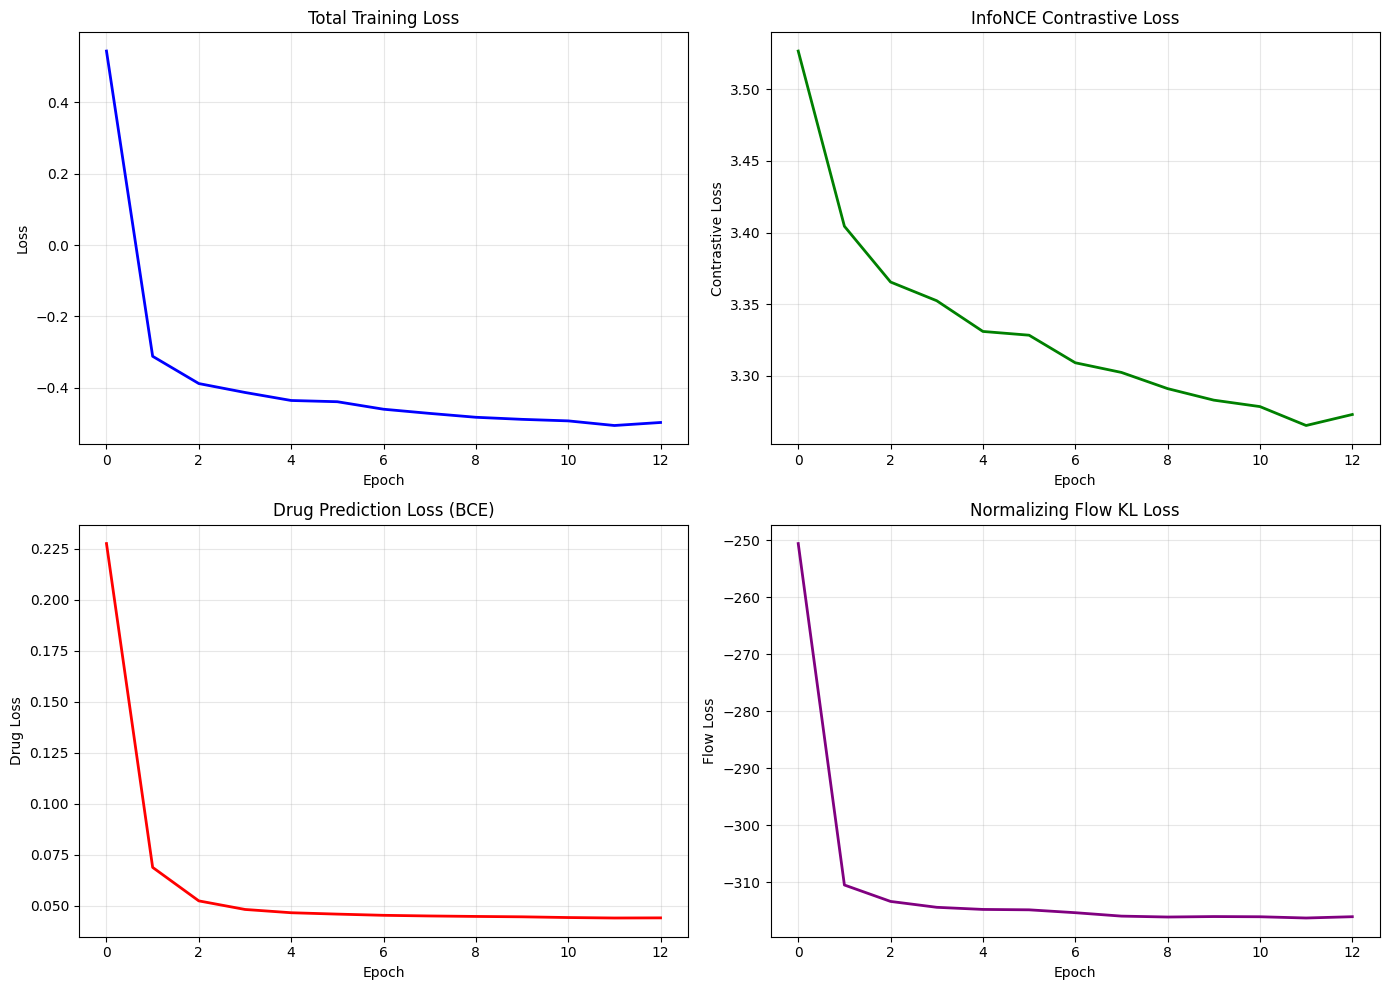


📊 Final Training Loss: -0.4977

🎨 LATENT SPACE VISUALIZATION


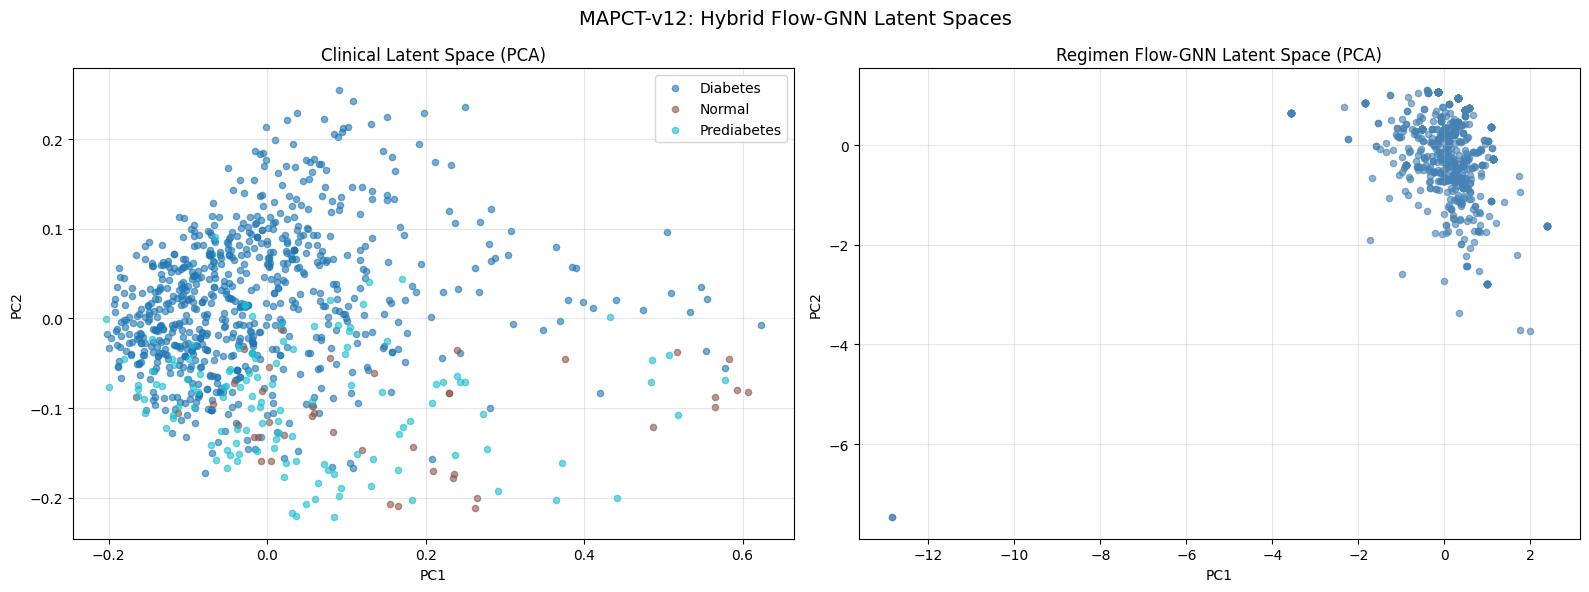


🎨 T-SNE LATENT SPACE VISUALIZATION


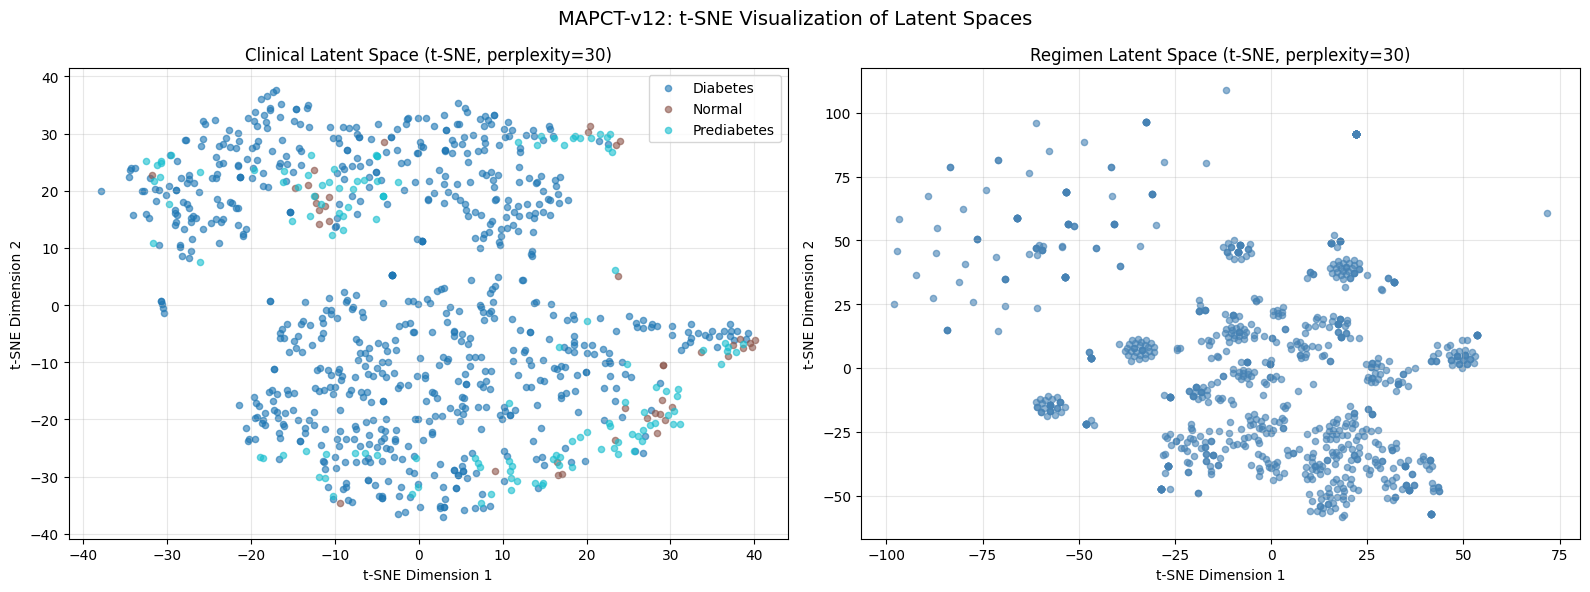

✅ t-SNE plot saved as 'mapct_v12_latent_tsne.png'

🎨 UMAP LATENT SPACE VISUALIZATION


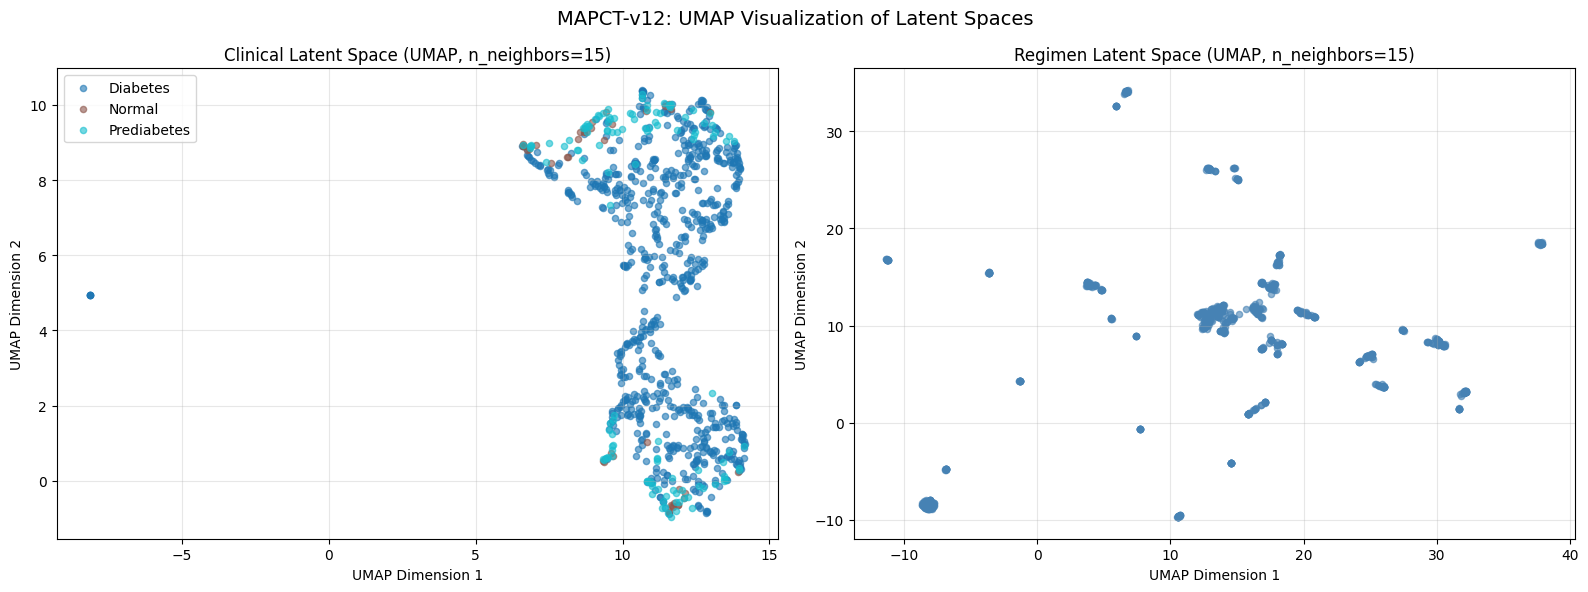

✅ UMAP plot saved as 'mapct_v12_latent_umap.png'

🔗 CLINICAL-REGIMEN ALIGNMENT ANALYSIS


Computing alignment: 100%|██████████| 29/29 [00:00<00:00, 67.04it/s]


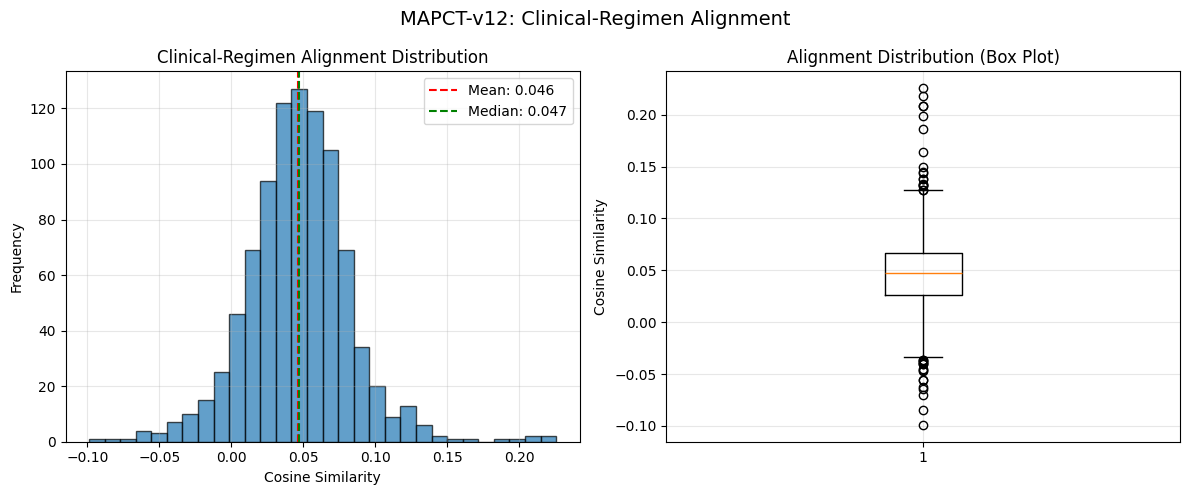


📊 Alignment Statistics:
   Mean: 0.0465
   Std:  0.0362
   Min:  -0.0989
   Max:  0.2256
   Median: 0.0470

🎯 JOINT LATENT SPACE VISUALIZATION


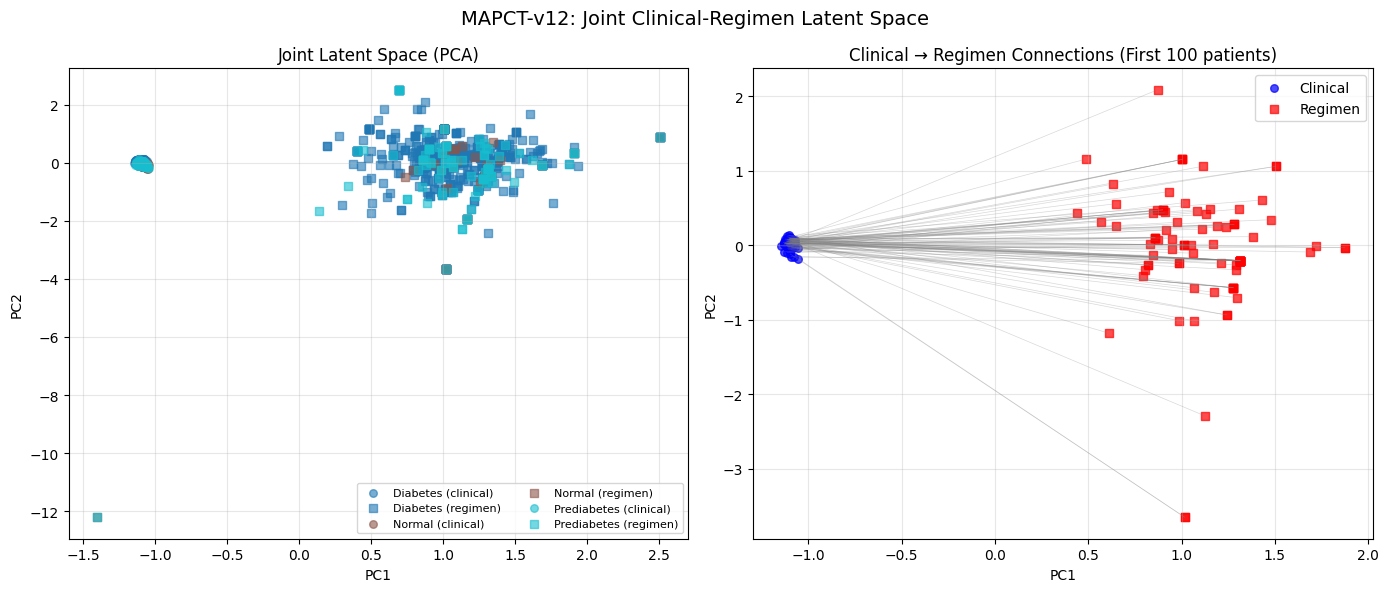


📊 Clinical-Regimen PCA Distances:
   Mean distance: 2.3493
   Std distance: 0.6043

🎨 JOINT LATENT SPACE – t‑SNE (Clinical + Regimen)


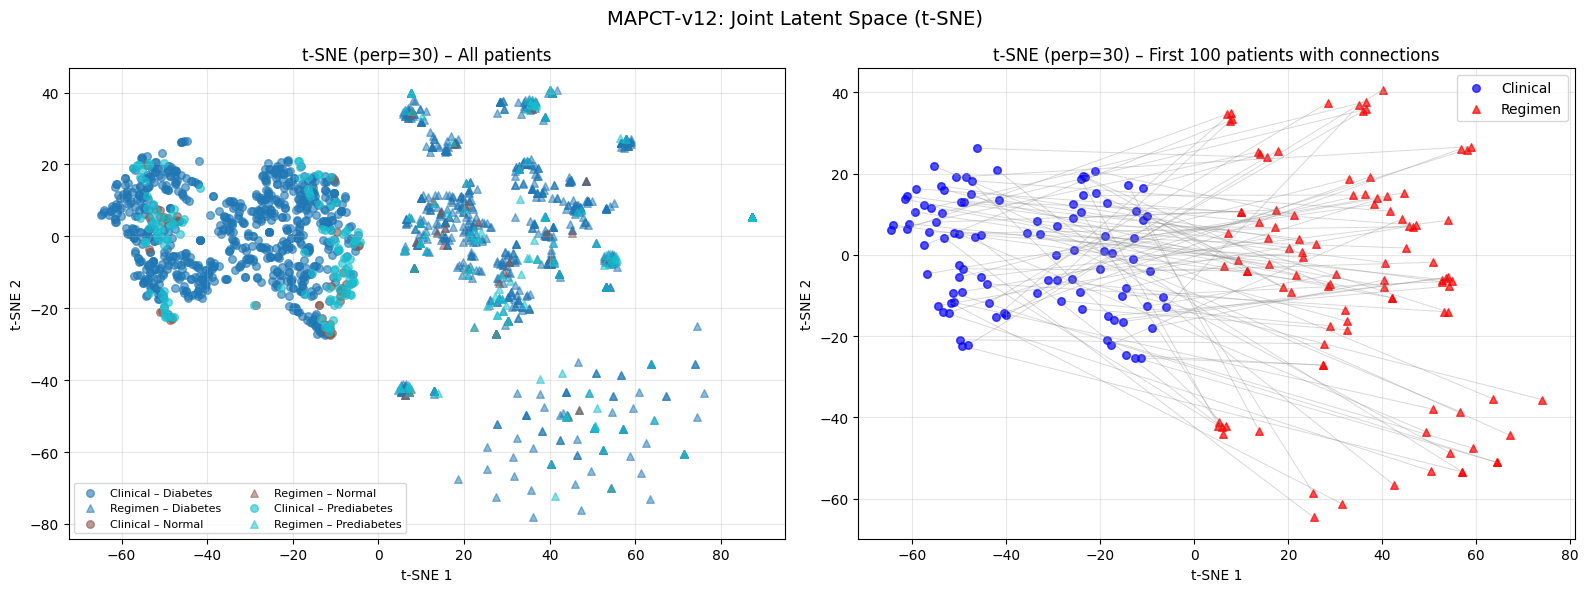


📊 Average t‑SNE distance between clinical and regimen points: 71.5217

🎨 JOINT LATENT SPACE – UMAP (Clinical + Regimen)


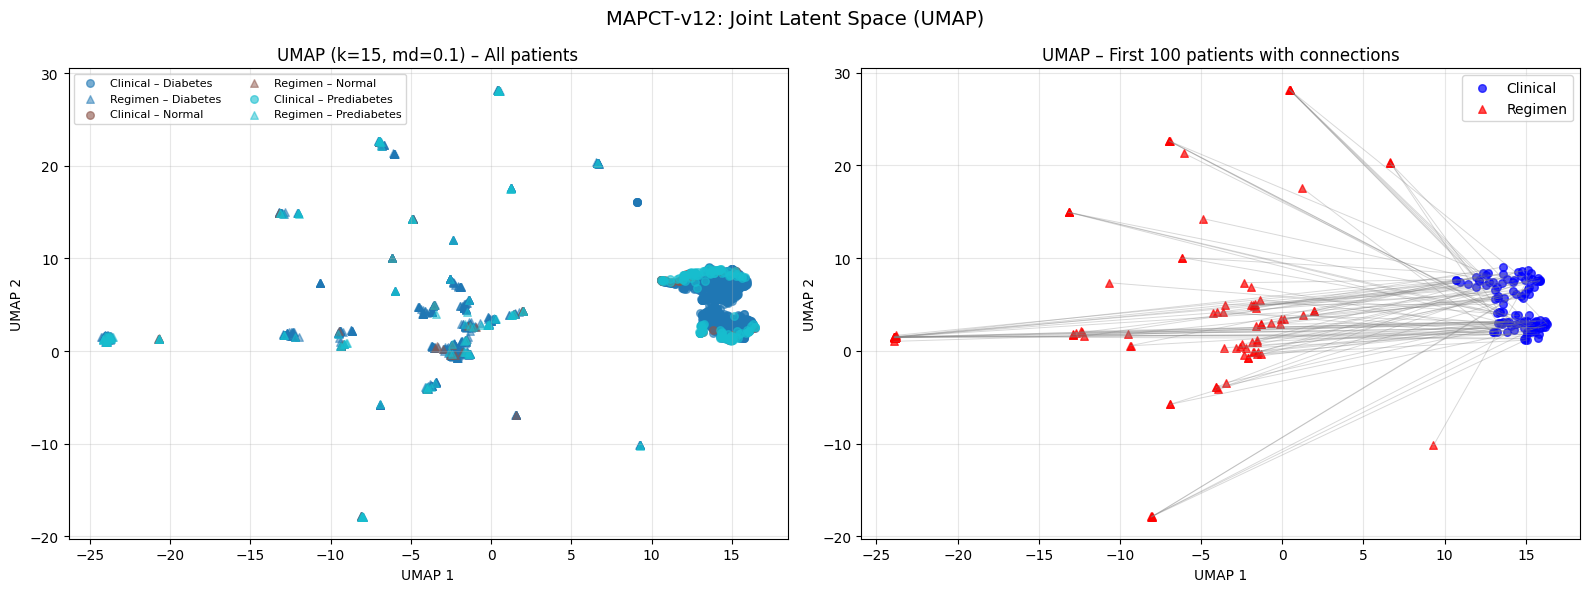


📊 Average UMAP distance between clinical and regimen points: 23.2292

🎨 GENERATING EXAMPLE REGIMENS

📋 Generated regimens for sample patient:

1. metformin, atorvastatin, losartan, aspirin
   Confidence: 0.769 | Number of drugs: 4
   Top drugs: metformin, atorvastatin, losartan

🔍 PATIENT-LEVEL ANALYSIS (First 3 test patients)

🩺 PATIENT #0 ANALYSIS

📊 CLINICAL PROFILE:
   fbs            : 98.00
   glu            : 204.00
   hba1c          : 7.70
   TG             : 176.00
   cho            : 188.00
   LDL            : 121.00
   HDL            : 39.00
   UA             : 5.63
   Na             : 132.00
   K              : 4.60
   Ca             : 9.37
   Vit D          : 14.23
   age            : 67.00
   sex            : 1
   fbs_category   : Good controlled
   tg_category    : Borderline High (Moderate risk)
   cho_category   : Desirable (Low cardiovascular risk)

💊 ACTUAL REGIMEN: aspirin, insulin aspart, insulin glargine, losartan, metformin

🤖 PREDICTED REGIMEN (threshold=0.3):
 

In [ ]:
# ============================================================
# SECTION 12: MAIN EXECUTION (COMPLETE WITH ALL FIXES)
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("🚀 MAPCT-v12: HYBRID NORMALIZING FLOW + GNN")
    print("="*80)

    # Check torch_geometric availability
    if not TORCH_GEOMETRIC_AVAILABLE:
        print("\n❌ ERROR: torch_geometric is required")
        exit(1)

    # Initialize model
    clin_dim = X_train.shape[1]
    model = MAPCTv12Hybrid(
        clin_dim=clin_dim,
        num_drugs=num_drugs,
        drug_graph_edge_index=drug_edge_index,
        drug_graph_weights=drug_edge_weights,
        latent_dim=128,
        n_flow_layers=4,
        gnn_type='gat',
        n_gnn_layers=2
    ).to(device)

    print(f"\n✅ Model initialized:")
    print(f"   Clinical input dim: {clin_dim}")
    print(f"   Drug vocabulary size: {num_drugs}")
    print(f"   Flow layers: 4")
    print(f"   GNN type: GAT")
    print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Create trainer
    trainer = MAPCTv12Trainer(model, device, drug_vocab, drug_to_idx, drug_edge_index)

    # Check if we should load existing model or train new
    CHECKPOINT_PATH = '/content/drive/MyDrive/khezri/mapct_v12_model.pt'
    retrain = True  # Set to False to load existing model

    if os.path.exists(CHECKPOINT_PATH) and not retrain:
        print(f"\n📂 Loading existing model from {CHECKPOINT_PATH}")
        trainer.load_checkpoint(CHECKPOINT_PATH)
    else:
        if os.path.exists(CHECKPOINT_PATH):
            print(f"\n⚠️ Existing checkpoint found – will overwrite with new training.")

        # Train model
        print("\n" + "="*80)
        print("🎯 STARTING HYBRID FLOW-GNN TRAINING")
        print("="*80)
        print(f"   Loss weights - Contrast: {trainer.alpha_contrast}, Drug: {trainer.beta_drug}, Flow: {trainer.gamma_flow}, Graph: {trainer.delta_graph}")

        history = trainer.train(train_loader, val_loader, epochs=50, patience=10)

        # Save best model
        trainer.save_checkpoint(CHECKPOINT_PATH)

    # Load best model (ensure we have the best version)
    trainer.load_checkpoint('best_flow_gnn_model.pt')

    # ========== VERIFY LATENT SPACES ==========
    print("\n" + "="*60)
    print("🔍 VERIFYING LATENT SPACES")
    print("="*60)

    # Quick verification function
    def verify_latent_spaces_quick(model, test_loader, device):
        """Quick verification that latent spaces exist"""
        model.eval()
        batch = next(iter(test_loader))

        clinical = batch['clinical'].to(device)
        mech_tensor = batch['mech_tensor'].to(device)
        mech_mask = batch['mech_mask'].to(device)
        drug_indices = batch['drug_indices'].to(device)

        with torch.no_grad():
            logits, z_clin, z_reg, z_gnn, z_seq = model(clinical, mech_tensor, mech_mask, drug_indices)

        print(f"✅ Clinical latent space (z_clin): shape={z_clin.shape}, std={z_clin.std().item():.4f}")
        print(f"✅ Regimen latent space (z_reg): shape={z_reg.shape}, std={z_reg.std().item():.4f}")
        print(f"✅ GNN output (z_gnn): shape={z_gnn.shape}")
        print(f"✅ Transformer output (z_seq): shape={z_seq.shape}")

        # Check for NaN/Inf
        if torch.isnan(z_clin).any() or torch.isinf(z_clin).any():
            print("⚠️ WARNING: NaN/Inf detected in clinical latent space!")
        if torch.isnan(z_reg).any() or torch.isinf(z_reg).any():
            print("⚠️ WARNING: NaN/Inf detected in regimen latent space!")

        return z_clin, z_reg

    z_clin_test, z_reg_test = verify_latent_spaces_quick(model, test_loader, device)

    # ========== COMPUTE TEST LATENTS ==========
    print("\n⏳ Computing full test latents...")
    z_clin_full, z_reg_full = compute_test_latents(model, test_loader, device)
    print(f"✅ Clinical latents shape: {z_clin_full.shape}")
    print(f"✅ Regimen latents shape: {z_reg_full.shape}")

    # ========== DRUG PREDICTION EVALUATION ==========
    results = evaluate_drug_predictions(trainer, test_loader, threshold=0.3)

    # ========== COMPREHENSIVE METRICS ==========
    print("\n" + "="*60)
    print("📊 COMPUTING COMPREHENSIVE METRICS")
    print("="*60)

    comprehensive_results = compute_comprehensive_metrics(
        model, test_loader, drug_vocab, device,
        threshold=0.3, num_stochastic=5
    )

    # ========== SAVE METRICS (JSON with FIX) ==========
    print("\n💾 Saving metrics...")

    # Helper function to fix numpy types
    def fix_numpy_types(obj):
        """Convert numpy types to Python native types for JSON"""
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        elif isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, torch.Tensor):
            return obj.cpu().numpy().tolist()
        elif isinstance(obj, dict):
            return {k: fix_numpy_types(v) for k, v in obj.items()}
        elif isinstance(obj, (list, tuple)):
            return [fix_numpy_types(item) for item in obj]
        return obj

    # Save with multiple formats for safety
    try:
        # JSON format
        fixed_results = fix_numpy_types(comprehensive_results)
        with open('mapct_v12_metrics.json', 'w') as f:
            json.dump(fixed_results, f, indent=4)
        print("✅ Metrics saved to mapct_v12_metrics.json")
    except Exception as e:
        print(f"⚠️ JSON save failed: {e}")

        # Text format backup
        with open('mapct_v12_metrics.txt', 'w') as f:
            f.write("MAPCT-v12 Evaluation Results\n")
            f.write("="*40 + "\n")
            for key, value in comprehensive_results.items():
                f.write(f"{key}: {value}\n")
        print("✅ Metrics saved to mapct_v12_metrics.txt")

        # Pickle backup
        import pickle
        with open('mapct_v12_metrics.pkl', 'wb') as f:
            pickle.dump(comprehensive_results, f)
        print("✅ Metrics saved to mapct_v12_metrics.pkl")

    # Print summary to console
    print("\n" + "="*60)
    print("📊 FINAL RESULTS SUMMARY")
    print("="*60)
    for key, value in comprehensive_results.items():
        if isinstance(value, float):
            print(f"   {key:<20}: {value:.4f}")
        else:
            print(f"   {key:<20}: {value}")
    print("="*60)

    # ========== VISUALIZATIONS ==========
    print("\n" + "="*60)
    print("🎨 GENERATING VISUALIZATIONS")
    print("="*60)

    # 1. Training history plots (if available)
    if trainer.history.get('loss'):
        plot_training_history(trainer, save_path='mapct_v12_training_history.png')
    else:
        print("⚠️ No training history available - skipping training plots")

    # 2. PCA Latent space visualization
    if len(z_clin_full) > 0 and len(z_reg_full) > 0:
        visualize_latent_spaces(z_clin_full, z_reg_full, test_df,
                               save_path='mapct_v12_latent_pca.png')
    else:
        print("⚠️ No latent vectors available - skipping PCA visualization")

    # 3. t-SNE visualization
    if len(z_clin_full) > 0 and len(z_reg_full) > 0:
        visualize_tsne_latent_spaces(
            z_clin_full, z_reg_full, test_df,
            save_path='mapct_v12_latent_tsne.png',
            perplexity=30
        )
    else:
        print("⚠️ No latent vectors available - skipping t-SNE visualization")

    # 4. UMAP visualization (if available)
    if UMAP_AVAILABLE and len(z_clin_full) > 0 and len(z_reg_full) > 0:
        visualize_umap_latent_spaces(
            z_clin_full, z_reg_full, test_df,
            save_path='mapct_v12_latent_umap.png',
            n_neighbors=15
        )
    else:
        print("⚠️ UMAP not available or no latent vectors - skipping UMAP")

    # 5. Alignment visualization (ONLY ONCE - FIXED)
    alignment_scores = visualize_alignment_v12(
        trainer, test_loader, device,
        save_path='mapct_v12_alignment.png'
    )

    # 6. Joint latent space visualization
    visualize_joint_latent_space(
        z_clin_full, z_reg_full, test_df,
        save_path='mapct_v12_joint_latent.png'
    )

    # Joint t‑SNE
    visualize_joint_tsne(z_clin_full, z_reg_full, test_df,
                        save_path='mapct_v12_joint_tsne.png',
                        perplexity=30, max_lines=100)

    # Joint UMAP (if available)
    if UMAP_AVAILABLE:
        visualize_joint_umap(z_clin_full, z_reg_full, test_df,
                            save_path='mapct_v12_joint_umap.png',
                            n_neighbors=15, min_dist=0.1, max_lines=100)

    # ========== GENERATE EXAMPLE REGIMENS ==========
    print("\n" + "="*70)
    print("🎨 GENERATING EXAMPLE REGIMENS")
    print("="*70)

    try:
        sample_batch = next(iter(test_loader))
        sample_clinical = sample_batch['clinical'][:1].to(device)

        generated = model.generate_regimens(sample_clinical, drug_vocab, num_samples=5, threshold=0.3)

        print("\n📋 Generated regimens for sample patient:")
        for i, gen in enumerate(generated, 1):
            print(f"\n{i}. {gen['regimen']}")
            print(f"   Confidence: {gen['confidence']:.3f} | Number of drugs: {gen['num_drugs']}")
            if gen['drugs']:
                print(f"   Top drugs: {', '.join([d for d, _ in gen['drugs'][:3]])}")
    except Exception as e:
        print(f"⚠️ Could not generate regimens: {e}")

    # ========== PATIENT-LEVEL ANALYSIS ==========
    print("\n" + "="*70)
    print("🔍 PATIENT-LEVEL ANALYSIS (First 3 test patients)")
    print("="*70)

    # Use z_clin_full for similarity search (FIXED)
    for idx in range(min(3, len(test_df))):
        try:
            show_patient_analysis(
                idx, model, test_dataset, test_df, drug_vocab,
                idx_to_drug, z_clin_full, device, threshold=0.3  # Changed from z_clin_test to z_clin_full
            )
        except Exception as e:
            print(f"⚠️ Could not analyze patient {idx}: {e}")

    # ========== DIAGNOSTIC FOR ALIGNMENT ISSUE ==========
    if comprehensive_results.get('alignment', 0) < 0.1:
        print("\n" + "="*70)
        print("⚠️ LOW ALIGNMENT DETECTED - DIAGNOSTIC INFO")
        print("="*70)
        print(f"Current alignment score: {comprehensive_results['alignment']:.4f}")
        print("\nSuggested fixes for next training run:")
        print("   1. Increase contrast weight (alpha_contrast) to 1.0")
        print("   2. Decrease flow weight (gamma_flow) to 0.001")
        print("   3. Reduce learning rate to 5e-4")
        print("   4. Add more epochs with early stopping patience 15")
        print("\nExample trainer configuration:")
        print("   self.alpha_contrast = 1.0   # Maximum alignment")
        print("   self.beta_drug = 0.5        # Reduce drug loss")
        print("   self.gamma_flow = 0.001     # Minimal flow reg")
        print("   self.delta_graph = 0.001    # Minimal graph reg")

    # Optional: Run alignment diagnostic (uncomment if needed)
    # Z_clin_diag, Z_reg_diag = diagnose_alignment_issue(model, test_loader, device)

    # ========== SAVE FINAL MODEL ==========
    try:
        trainer.save_checkpoint('/content/drive/MyDrive/khezri/mapct_v12_final.pt')
        print("\n✅ Final model saved to Google Drive")
    except Exception as e:
        print(f"\n⚠️ Could not save to Google Drive: {e}")
        trainer.save_checkpoint('mapct_v12_final_local.pt')
        print("✅ Final model saved locally as 'mapct_v12_final_local.pt'")

    # ========== CLEANUP ==========
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("\n✅ GPU cache cleared")

    # ========== COMPLETION ==========
    print("\n" + "="*80)
    print("✅ MAPCT-v12 COMPLETE!")
    print("="*80)
    print("Summary of saved files:")
    print("   - mapct_v12_metrics.json (or .txt/.pkl) - Evaluation metrics")
    print("   - mapct_v12_training_history.png - Training curves")
    print("   - mapct_v12_latent_pca.png - PCA visualization")
    print("   - mapct_v12_latent_tsne.png - t-SNE visualization")
    print("   - mapct_v12_latent_umap.png - UMAP visualization")
    print("   - mapct_v12_alignment.png - Alignment distribution")
    print("   - mapct_v12_joint_latent.png - Joint latent space")
    print("   - best_flow_gnn_model.pt - Best model checkpoint")
    print("   - mapct_v12_final.pt - Final model")
    print("="*80)